<a href="https://colab.research.google.com/github/zoedoey/COMPSCI-184A-Final-Project/blob/main/CS_178_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# Imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 1234

In [13]:
pip install ucimlrepo

In [14]:
# display(pd.read_csv(diabetes_130_us_hospitals_for_years_1999_2008.metadata.data_url))

In [15]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)

# data (as pandas dataframes)
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets

y = y.squeeze()

# Remove features with > 80% missing data (weight, max_glu_serum, A1Cresult)
# We could change this / decide to do something else

X = X.drop(columns=["weight", "max_glu_serum", "A1Cresult"])
print("X Shape:", X.shape)

seed = 1234

# Split total data into 80% train/val, 20% test
X_tr_val, X_te_original, y_tr_val, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

# Split the train/val into 75% train and 25% val
# i.e. train = 60% of total, val = 20% of total, & test = 20% of total
X_tr_original, X_val_original, y_tr, y_val = train_test_split(X_tr_val, y_tr_val, test_size=0.25, random_state=seed, stratify=y_tr_val)

print("Train:", X_tr_original.shape, y_tr.shape)
print("Val  :", X_val_original.shape, y_val.shape)
print("Test :", X_te_original.shape, y_te.shape)

### This preprocessing should be okay for kNN, logistic classification, & neural nets,
### but depending on the fourth model, (e.g., Random Forest), we might want to use
### different preprocessing
### this is why I named the split data (above) with X_**_original if we want to do something different

# separate columns containing numerical data from categorical data
numeric_cols = X_tr_original.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_tr_original.select_dtypes(include=["object", "category"]).columns

# imputer replaces missing values with median of that column
# - we could change to mean or something else
# scaler scales the features
numeric_steps = [("imputer", SimpleImputer(strategy="median")),
                 ("scaler", StandardScaler())]

# imputer replaces missing values with the most common category from that column
# onehot converts the categories into a numerical, binary encoding
categorical_steps = [("imputer", SimpleImputer(strategy="most_frequent")),
                     ("onehot", OneHotEncoder(handle_unknown="ignore"))]

# create the pipelines with the steps above
numeric_data_transform = Pipeline(numeric_steps)
categorical_data_transform = Pipeline(categorical_steps)

# create the preprocessor with all the transformations
preprocessor_oh = ColumnTransformer(
    transformers=[
        ("numeric", numeric_data_transform, numeric_cols),
        ("categorical", categorical_data_transform, categorical_cols)
    ],
    remainder="drop"
)

# Ordinal Encoding
categorical_steps_ord = [("imputer", SimpleImputer(strategy="most_frequent")),
                     ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]

categorical_data_transform_ord = Pipeline(categorical_steps_ord)

preprocessor_ord = ColumnTransformer(
    transformers=[
        ("numeric", numeric_data_transform, numeric_cols),
        ("categorical", categorical_data_transform_ord, categorical_cols)
    ],
    remainder="drop"
)

# Fit & transform on the training data
X_tr_oh = preprocessor_oh.fit_transform(X_tr_original)
X_tr = preprocessor_ord.fit_transform(X_tr_original)

# Transform only on val and test data
X_val_oh = preprocessor_oh.transform(X_val_original)
X_te_oh = preprocessor_oh.transform(X_te_original)

X_val = preprocessor_ord.transform(X_val_original)
X_te = preprocessor_ord.transform(X_te_original)

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


X Shape: (101766, 44)
Train: (61059, 44) (61059,)
Val  : (20353, 44) (20353,)
Test : (20354, 44) (20354,)


Accuracy: 58.92%
Training Accuracy: 100.00%
Validation Accuracy: 58.92%


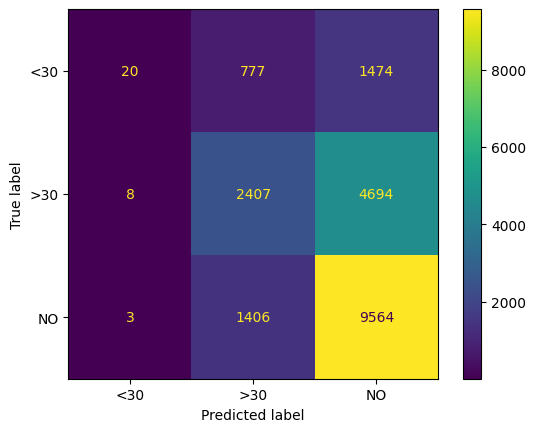

              precision    recall  f1-score   support

         <30       0.65      0.01      0.02      2271
         >30       0.52      0.34      0.41      7109
          NO       0.61      0.87      0.72     10973

    accuracy                           0.59     20353
   macro avg       0.59      0.41      0.38     20353
weighted avg       0.58      0.59      0.53     20353



In [17]:
# Initial training, n_estimators was a randomly chosen value
classifier = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
classifier.fit(X_tr_oh, y_tr)
y_hat = classifier.predict(X_val_oh)

# Evaluation
accuracy = accuracy_score(y_val, y_hat)
print(f"Accuracy: {accuracy * 100:.2f}%")

train_acc = classifier.score(X_tr_oh, y_tr)
val_acc = classifier.score(X_val_oh, y_val)
print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

ConfusionMatrixDisplay.from_predictions(y_val, y_hat)
plt.show()

print(classification_report(y_val, y_hat))

In [18]:
classes = np.unique(y_tr)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
class_weights = dict(zip(classes, class_weights))
print(class_weights)

{'<30': np.float64(2.9869386557088347), '>30': np.float64(0.9543301917756835), 'NO': np.float64(0.6182939425238472)}


In [19]:
# Tuning
'''
Hyperparameters:
n_estimators = Number of trees in the forest
max_depth = Maximum depth of the tree
max_features = Maximum number of features to consider when looking for the best split
criterion = The function to measure the quality of a split
min_samples_leaf = Minimum number of samples required to be at a leaf node
min_samples_split = Minimum number of samples required to split an internal node
bootstrap = Whether bootstrap samples are used when building trees
'''
estimator = RandomForestClassifier(random_state=RANDOM_STATE, class_weight=class_weights)

param_grid = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [10, 15, 20, 30 , None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 20, 50],
}
rf_random = RandomizedSearchCV(estimator=estimator, param_distributions=param_grid, n_iter=60, scoring='f1_macro', cv=5, verbose=2, random_state=RANDOM_STATE, n_jobs=-1)
rf_random.fit(X_tr, y_tr)
print(rf_random.best_params_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 30}


Accuracy: 55.76%
Training Accuracy: 76.25%
Validation Accuracy: 55.76%


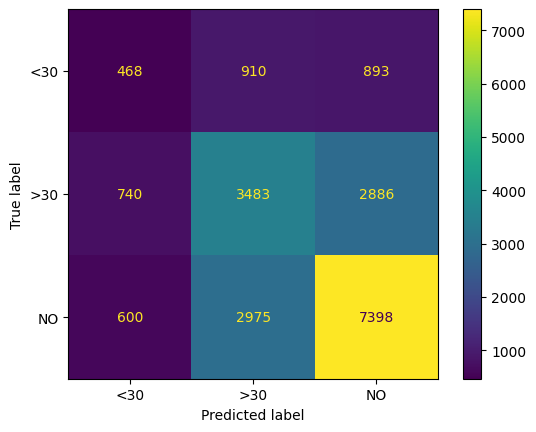

              precision    recall  f1-score   support

         <30       0.26      0.21      0.23      2271
         >30       0.47      0.49      0.48      7109
          NO       0.66      0.67      0.67     10973

    accuracy                           0.56     20353
   macro avg       0.46      0.46      0.46     20353
weighted avg       0.55      0.56      0.55     20353



In [23]:
# Tuned classifier
best_rf = RandomForestClassifier(n_estimators=500, min_samples_split=20, min_samples_leaf=10, max_features='sqrt', max_depth=30, bootstrap=True, class_weight=class_weights)
best_rf.fit(X_tr, y_tr)
y_hat = best_rf.predict(X_val)

# Evaluation
accuracy = accuracy_score(y_val, y_hat)
print(f"Accuracy: {accuracy * 100:.2f}%")

train_acc = best_rf.score(X_tr, y_tr)
val_acc = best_rf.score(X_val, y_val)
print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

ConfusionMatrixDisplay.from_predictions(y_val, y_hat)
plt.show()

print(classification_report(y_val, y_hat))

Accuracy: 56.13%
Training Accuracy: 76.25%
Test Accuracy: 56.13%


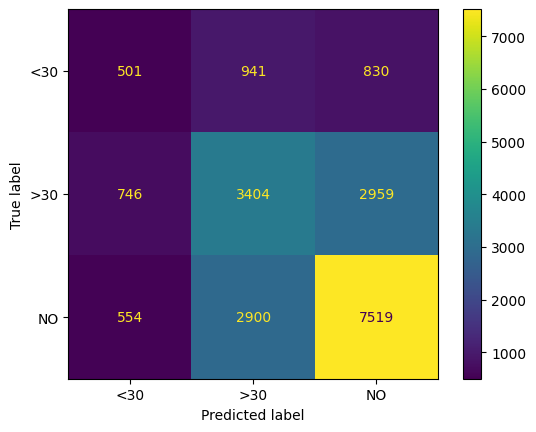

              precision    recall  f1-score   support

         <30       0.28      0.22      0.25      2272
         >30       0.47      0.48      0.47      7109
          NO       0.66      0.69      0.67     10973

    accuracy                           0.56     20354
   macro avg       0.47      0.46      0.47     20354
weighted avg       0.55      0.56      0.56     20354



In [24]:
# Classifier on test data
y_hat = best_rf.predict(X_te)

# Evaluation
accuracy = accuracy_score(y_te, y_hat)
print(f"Accuracy: {accuracy * 100:.2f}%")

train_acc = best_rf.score(X_tr, y_tr)
test_acc = best_rf.score(X_te, y_te)
print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

ConfusionMatrixDisplay.from_predictions(y_te, y_hat)
plt.show()

print(classification_report(y_te, y_hat))